In [3]:
import numpy as np
import matplotlib.pyplot as plt

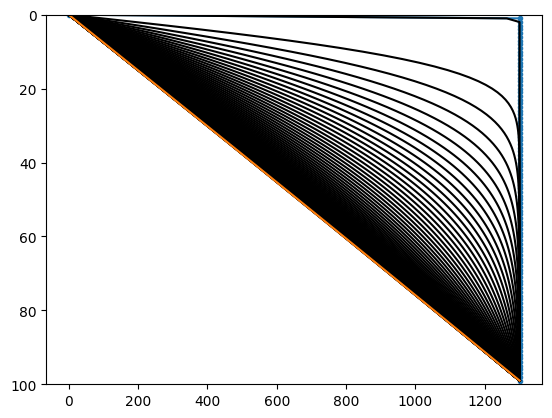

In [15]:
L = 100_000.0
dz = 1000.0

z = np.arange(0.0,L,dz)
T = z*0+1300.0
T[0] = 0.0

plt.plot(T,z/1000,".-")
plt.ylim(100,0)

dt = 1000.0 # Passo de tempo em anos
kappa = 0.9E-6 # Difusividade térmica (m2/s)
seg_por_ano = 365.0*24.0*60.0*60.0

f = dt*seg_por_ano*kappa/dz**2

t=0.0
t_max = 180.0E6

t_print=0.0

qq=[]
tt=[]
k = 3.3 #W/(K*m) condutividade térmica

while t<t_max:
  if t>t_print:
    plt.plot(T,z/1000,"k")
    t_print+=2.0E6
    qq = np.append(qq,k*(T[1]-T[0])/dz)
    tt = np.append(tt,t)
  T[1:-1] += f*(T[2:]-2*T[1:-1]+T[:-2])
  t+=dt

plt.plot(T,z/1000)

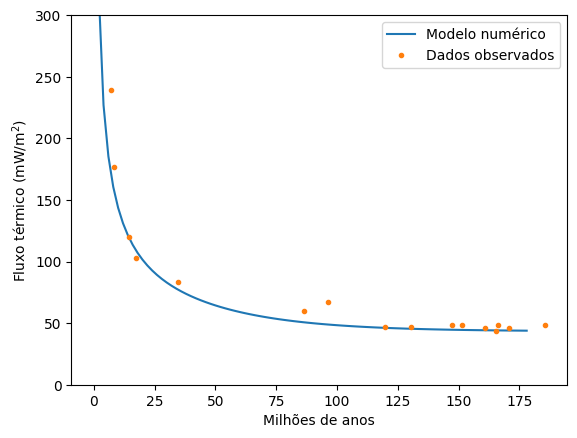

In [20]:
plt.plot(tt/1.0E6,qq*1000,label="Modelo numérico")
plt.ylim(0.0,300.0)
plt.xlabel("Milhões de anos")
plt.ylabel("Fluxo térmico (mW/m$^2$)")

to,qo = np.loadtxt("https://raw.githubusercontent.com/victorsacek/CursoPetrobras/master/fluxo_termico.txt"
          ,unpack=True)
plt.plot(to,qo,".",label="Dados observados")
plt.legend()
